<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Aula_2_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas para Análise de Dados

### Instalação do Pandas (Se Necessário)

Na maioria dos ambientes de desenvolvimento Python (como o Google Colab, Anaconda, ou instalações modernas), o Pandas já vem pré-instalado. No entanto, se você precisar instalá-lo, pode usar o pip, o gerenciador de pacotes do Python:

```bash
pip install pandas
```

Se você estiver usando ambientes como o Anaconda, pode ser que prefira usar o conda:

```bash
conda install pandas
```

**Observação**: No Google Colab, você geralmente não precisa instalar o Pandas, pois ele já está disponível por padrão.

In [1]:
# Importando a biblioteca Pandas
import pandas as pd
import numpy as np # Útil para manipulação de dados

# Vamos configurar a exibição para que o Pandas não corte as colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## O que é o Pandas e para que é usado?

**Pandas** é uma biblioteca de código aberto em Python que fornece estruturas de dados de alto desempenho e ferramentas fáceis de usar para análise e manipulação de dados. É uma das ferramentas mais populares e essenciais para cientistas de dados e analistas.

**Para que é usado?**

1.  **Manipulação de Dados**: Oferece funcionalidades para carregar, limpar, transformar e organizar dados de diversas fontes (CSV, Excel, SQL, JSON, etc.).
2.  **Análise de Dados**: Permite realizar operações como filtragem, seleção, agregação (soma, média, contagem), junções de tabelas e cálculo de estatísticas descritivas de forma eficiente.
3.  **Preparação para Machine Learning**: É fundamental para pré-processar os dados antes de alimentá-los em modelos de Machine Learning, lidando com valores ausentes, codificação de variáveis categóricas e normalização.
4.  **Séries Temporais**: Possui excelentes ferramentas para trabalhar com dados temporais, facilitando a análise de tendências e padrões ao longo do tempo.
5.  **Visualização**: Integra-se facilmente com bibliotecas de visualização como Matplotlib e Seaborn para criar gráficos e entender melhor os dados.

Em resumo, o Pandas é a "caixa de ferramentas" indispensável para transformar dados brutos em insights acionáveis.

## 1. Introdução e Estruturas de Dados

O Pandas introduz duas estruturas de dados principais, a Series e o DataFrame, que são a base para a manipulação de dados em Python:

*   **Series (Unidimensional)**: Pense em uma Series como uma única coluna de uma planilha ou um array NumPy com um rótulo (índice) para cada elemento. É capaz de armazenar qualquer tipo de dado (inteiros, strings, floats, objetos Python, etc.).

*   **DataFrame (Bidimensional)**: Um DataFrame é a estrutura de dados mais usada no Pandas. É uma tabela com linhas e colunas, semelhante a uma planilha Excel, um banco de dados SQL ou um dicionário de objetos Series. Cada coluna de um DataFrame é uma Series.

### Ação: Carregar um CSV/Excel

Vamos começar carregando um dataset de vendas de e-commerce. Usaremos o dataset 'Online Retail' da UCI, que é um arquivo Excel. Primeiro, vamos baixá-lo.

In [4]:
# Baixando o dataset de Vendas de E-commerce (Online Retail)
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

# Carregando o arquivo Excel em um DataFrame
df_ecommerce = pd.read_excel('Online Retail.xlsx')

# Comandos essenciais para inspecionar o DataFrame
print('Primeiras 5 linhas do DataFrame:')
display(df_ecommerce.head())

print('\nInformações gerais sobre o DataFrame (tipos de dados, valores não nulos):')
df_ecommerce.info()

print('\nEstatísticas descritivas básicas do DataFrame:')
display(df_ecommerce.describe())

Primeiras 5 linhas do DataFrame:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Informações gerais sobre o DataFrame (tipos de dados, valores não nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Estatísticas descritivas básicas do DataFrame:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 2. Seleção e Filtragem (O "Coração" do Pandas)

Selecionar e filtrar dados é fundamental no Pandas. Duas propriedades principais são usadas para acessar dados:

*   `.loc[]`: Seleção baseada em **rótulos** (nomes de linhas e colunas).
*   `.iloc[]`: Seleção baseada em **índices numéricos** (posição inteira).

### Exemplos Práticos

In [ ]:
# Exemplo 1: Filtragem booleana complexa
# Filtrando descrições que contém 'BAG' e quantidade > 10
filtro = (df_ecommerce['Description'].str.contains('BAG', na=False)) & (df_ecommerce['Quantity'] > 10)
display(df_ecommerce[filtro].head())

# Exemplo 2: loc vs iloc
print('Seleção por nome (loc) - Primeiras 5 linhas e colunas específicas:')
display(df_ecommerce.loc[0:4, ['InvoiceNo', 'Quantity']])

print('\nSeleção por posição (iloc) - Linhas 10 a 14 e colunas 0 a 2:')
display(df_ecommerce.iloc[10:15, 0:3])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
38,536370,22661,CHARLOTTE BAG DOLLY GIRL DESIGN,20,2010-12-01 08:45:00,0.85,12583.0,France
176,536386,85099C,JUMBO BAG BAROQUE BLACK WHITE,100,2010-12-01 09:57:00,1.65,16029.0,United Kingdom
177,536386,85099B,JUMBO BAG RED RETROSPOT,100,2010-12-01 09:57:00,1.65,16029.0,United Kingdom
234,536390,85099B,JUMBO BAG RED RETROSPOT,100,2010-12-01 10:19:00,1.65,17511.0,United Kingdom
482,536408,21705,BAG 500g SWIRLY MARBLES,12,2010-12-01 11:41:00,1.65,14307.0,United Kingdom


Seleção por nome (loc) - Primeiras 5 linhas e colunas específicas:


,InvoiceNo,Quantity
0,536365,6
1,536365,6
2,536365,8
3,536365,6
4,536365,6



Seleção por posição (iloc) - Linhas 10 a 14 e colunas 0 a 2:


,InvoiceNo,StockCode,Description
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN
12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL
13,536367,22310,IVORY KNITTED MUG COSY
14,536367,84969,BOX OF 6 ASSORTED COLOUR TEASPOONS


### Exemplos Adicionais de Seleção e Filtragem

In [7]:
# Exemplo: Usando .loc[] para selecionar linhas por rótulo e colunas específicas
# Seleciona as primeiras 5 linhas e as colunas 'InvoiceNo' e 'Quantity' por seus nomes.
exemplo_loc = df_ecommerce.loc[0:4, ['InvoiceNo', 'Quantity']]
print('\nExemplo de seleção com .loc[] (primeiras 5 linhas, colunas específicas):')
display(exemplo_loc)

# Exemplo: Usando .iloc[] para selecionar por posição numérica
# Seleciona as linhas de índice 10 a 14 e as colunas de índice 0 a 2.
exemplo_iloc = df_ecommerce.iloc[10:15, 0:3]
print('\nExemplo de seleção com .iloc[] (linhas 10-14, colunas 0-2):')
display(exemplo_iloc)

# Exemplo: Filtragem booleana com condição de texto
# Encontra produtos cuja descrição contém 'RED'
exemplo_filtro_texto = df_ecommerce[df_ecommerce['Description'].str.contains('RED', na=False)].head()
print('\nExemplo de filtro por texto na descrição (contém "RED"):')
display(exemplo_filtro_texto)

# Exemplo: Filtragem com múltiplas condições (OR)
# Encontra transações onde o País é 'Germany' OU 'France'
exemplo_filtro_or = df_ecommerce[(df_ecommerce['Country'] == 'Germany') | (df_ecommerce['Country'] == 'France')].head()
print('\nExemplo de filtro com OR (País "Germany" ou "France"):')
display(exemplo_filtro_or)


Exemplo de seleção com .loc[] (primeiras 5 linhas, colunas específicas):


,InvoiceNo,Quantity
0,536365,6
1,536365,6
2,536365,8
3,536365,6
4,536365,6



Exemplo de seleção com .iloc[] (linhas 10-14, colunas 0-2):


,InvoiceNo,StockCode,Description
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN
12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL
13,536367,22310,IVORY KNITTED MUG COSY
14,536367,84969,BOX OF 6 ASSORTED COLOUR TEASPOONS



Exemplo de filtro por texto na descrição (contém "RED"):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
22,536368,22913,RED COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047.0,United Kingdom
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
33,536370,21035,SET/2 RED RETROSPOT TEA TOWELS,18,2010-12-01 08:45:00,2.95,12583.0,France



Exemplo de filtro com OR (País "Germany" ou "France"):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France


### Exercício 2.1: Seleção com `.loc[]`

Selecione as colunas `InvoiceNo`, `Description` e `UnitPrice` para as primeiras 100 linhas do `df_ecommerce` usando `.loc[]` e exiba as 5 primeiras linhas do resultado.

In [11]:
exemplo_loc = df_ecommerce.loc[0:99, ['InvoiceNo', 'Description', 'UnitPrice']]

exemplo_loc.head()

,InvoiceNo,Description,UnitPrice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,2.55
1,536365,WHITE METAL LANTERN,3.39
2,536365,CREAM CUPID HEARTS COAT HANGER,2.75
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
4,536365,RED WOOLLY HOTTIE WHITE HEART.,3.39


### Exercício 2.2: Seleção com `.iloc[]`

Selecione as linhas de índice 100 a 105 (inclusive) e todas as colunas do `df_ecommerce` usando `.iloc[]`.

In [9]:
exemplo_iloc = df_ecommerce.iloc[100:106, :]

exemplo_iloc

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
100,536378,84519A,TOMATO CHARLIE+LOLA COASTER SET,6,2010-12-01 09:37:00,2.95,14688.0,United Kingdom
101,536378,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,2010-12-01 09:37:00,1.25,14688.0,United Kingdom
102,536378,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,2010-12-01 09:37:00,0.38,14688.0,United Kingdom
103,536378,21931,JUMBO STORAGE BAG SUKI,10,2010-12-01 09:37:00,1.95,14688.0,United Kingdom
104,536378,21929,JUMBO BAG PINK VINTAGE PAISLEY,10,2010-12-01 09:37:00,1.95,14688.0,United Kingdom
105,536380,22961,JAM MAKING SET PRINTED,24,2010-12-01 09:41:00,1.45,17809.0,United Kingdom


### Exercício 2.3: Filtragem Booleana Simples

Filtre o `df_ecommerce` para mostrar apenas as transações que ocorreram no `Country` 'France' e onde o `Quantity` foi maior que 5. Exiba as 10 primeiras linhas.

In [10]:
# Exemplo: Filtragem com múltiplas condições (OR)
# Encontra transações onde o País é 'Germany' OU 'France'
exemplo_filtro = df_ecommerce[(df_ecommerce['Country'] == 'France') & (df_ecommerce['Quantity'] > 5)]

exemplo_filtro.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France
32,536370,21791,VINTAGE HEADS AND TAILS CARD GAME,24,2010-12-01 08:45:00,1.25,12583.0,France
33,536370,21035,SET/2 RED RETROSPOT TEA TOWELS,18,2010-12-01 08:45:00,2.95,12583.0,France
34,536370,22326,ROUND SNACK BOXES SET OF4 WOODLAND,24,2010-12-01 08:45:00,2.95,12583.0,France
35,536370,22629,SPACEBOY LUNCH BOX,24,2010-12-01 08:45:00,1.95,12583.0,France


### Exercício 2.4: Filtragem Complexa

Filtre o `df_ecommerce` para encontrar transações onde o `UnitPrice` (preço unitário) é maior que 10 E o `StockCode` (código do item) **não** começa com a letra 'C' (que geralmente indica itens cancelados). Exiba as 5 primeiras linhas do resultado.

In [13]:
exemplo_filtro = df_ecommerce[(df_ecommerce['UnitPrice'] > 10) & (df_ecommerce['StockCode'].str.startswith('C'))]

exemplo_filtro.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.0,14911.0,EIRE
12119,537368,C2,CARRIAGE,1,2010-12-06 12:40:00,50.0,14911.0,EIRE
12452,537378,C2,CARRIAGE,1,2010-12-06 13:06:00,50.0,14911.0,EIRE
19975,537963,C2,CARRIAGE,1,2010-12-09 11:30:00,50.0,13369.0,United Kingdom
20016,538002,C2,CARRIAGE,1,2010-12-09 11:48:00,50.0,14932.0,Channel Islands


## 3. Limpeza de Dados (Data Wrangling)

Dados reais costumam ser 'sujos'. Precisamos tratar valores nulos e converter tipos:

*   `.fillna()`: Preenche lacunas.
*   `.dropna()`: Remove dados ausentes.
*   `.astype()`: Altera o tipo (ex: string para float).
*   `.rename()`: Renomeia colunas.

### Exemplos Práticos

### Preparação: Carregando o Titanic

Para esta seção, usaremos um dataset do Titanic. Vamos baixá-lo e carregá-lo.

In [ ]:
import pandas as pd
# Baixando o dataset do Titanic
!wget -q https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

# Carregando o DataFrame
df_titanic = pd.read_csv('titanic.csv')

print('Primeiras 5 linhas do Titanic:')
display(df_titanic.head())

print('\nInformações do Dataset:')
df_titanic.info()

Primeiras 5 linhas do Titanic:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Exemplos Práticos de Limpeza (Titanic)

Vamos tratar os dados do Titanic, lidando com nulos na idade e cabine, e convertendo tipos.

In [ ]:
# 1. Verificando nulos
print('Nulos por coluna:')
print(df_titanic.isnull().sum())

# 2. Preenchendo a idade (Age) com a média
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].mean())

# 3. Removendo a coluna 'Cabin' (muitos nulos)
df_titanic_limpo = df_titanic.drop(columns=['Cabin'])

# 4. Convertendo 'Fare' (Preço) para inteiro para simplificar
df_titanic_limpo['Fare_Int'] = df_titanic_limpo['Fare'].astype(int)

display(df_titanic_limpo.head())

Nulos por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_Int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,7
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,71
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,7
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,53
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,8


### Exemplos Adicionais de Limpeza de Dados (Titanic)

Vamos realizar mais algumas operações de limpeza, como tratar o porto de embarque e criar novas colunas baseadas em condições.

In [ ]:
# Removendo linhas onde o porto de embarque (Embarked) está faltando
df_titanic_limpo = df_titanic_limpo.dropna(subset=['Embarked'])

# Verificando se ainda existem nulos
print('Nulos após limpeza adicional:')
print(df_titanic_limpo.isnull().sum())

display(df_titanic_limpo.head())

Nulos após limpeza adicional:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Fare_Int       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fare_Int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,7
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,71
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,7
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,53
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,8


In [ ]:
# Escreva aqui

In [ ]:
# Criando uma cópia para demonstração de limpeza
df_limpeza = df_ecommerce.copy()

# 1. Identificar nulos
print('Contagem de nulos por coluna:')
print(df_limpeza.isnull().sum())

# 2. Preencher nulos (.fillna)
# Preenchendo descrições vazias com um texto padrão
df_limpeza['Description'] = df_limpeza['Description'].fillna('No Description Available')

# 3. Remover nulos (.dropna)
# Removendo linhas onde CustomerID é nulo
df_limpeza = df_limpeza.dropna(subset=['CustomerID'])

# 4. Conversão de tipos (.astype, pd.to_numeric)
# Convertendo CustomerID para inteiro (após remover nulos)
df_limpeza['CustomerID'] = df_limpeza['CustomerID'].astype(int)

# 5. Renomear colunas (.rename)
df_limpeza = df_limpeza.rename(columns={'InvoiceNo': 'ID_Fatura', 'Quantity': 'Qtd'})

display(df_limpeza.head())

Contagem de nulos por coluna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,ID_Fatura,StockCode,Description,Qtd,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


# Escreva aqui

### Exercício 3.1: Identificando Valores Nulos

No `df_titanic`, identifique quais colunas possuem valores nulos e calcule a porcentagem de nulos em cada uma.

In [ ]:
# Escreva aqui

### Exercício 3.2: Tratando o Porto de Embarque

A coluna `Embarked` possui alguns valores nulos no `df_titanic`. Preencha esses valores com a 'Moda' (o valor que mais se repete) da coluna.

### Exercício 3.2: Tratando o Porto de Embarque

A coluna `Embarked` possui alguns valores nulos. Preencha esses valores com a 'Moda' (o valor que mais se repete) da coluna.

In [ ]:
# Escreva aqui

### Exercício 3.3: Criando Faixas Etárias

No `df_titanic_limpo`, crie uma nova coluna chamada `IsMinor` que contenha `True` se o passageiro tiver menos de 18 anos e `False` caso contrário.

### Exercício 3.3: Criando Faixas Etárias

Crie uma nova coluna chamada `IsMinor` que contenha True se o passageiro tiver menos de 18 anos e False caso contrário.

In [ ]:
# Escreva aqui

### Exercício 3.4: Renomeando e Organizando

Usando o `df_titanic_limpo`, renomeie as colunas `Pclass` para `Classe` e `Survived` para `Sobreviveu`. Exiba as primeiras 5 linhas do DataFrame resultante.

In [ ]:
# Escreva aqui

## 4. Agregação e Transformação

Como resumir dados em insights usando `groupby` (Dividir-Aplicar-Combinar) e `Pivot Tables`.

### Exemplos Práticos

In [ ]:
# Primeiro, calculamos o faturamento total por linha
df_ecommerce['TotalPrice'] = df_ecommerce['Quantity'] * df_ecommerce['UnitPrice']

# Convertemos 'InvoiceDate' para datetime para extrair o mês
df_ecommerce['InvoiceDate'] = pd.to_datetime(df_ecommerce['InvoiceDate'])
df_ecommerce['Month'] = df_ecommerce['InvoiceDate'].dt.to_period('M')

# Agrupamos por País e Mês, somando o TotalPrice
faturamento_por_pais_mes = df_ecommerce.groupby(['Country', 'Month'])['TotalPrice'].sum().reset_index()
display(faturamento_por_pais_mes.head())

,Country,Month,TotalPrice
0,Australia,2010-12,1005.10
1,Australia,2011-01,9017.71
2,Australia,2011-02,14627.47
3,Australia,2011-03,17055.29
4,Australia,2011-04,333.40


### Exemplos Adicionais de Agregação e Transformação

In [ ]:
# Exemplo 1: Groupby com soma e média
agg_vendas = df_ecommerce.groupby('Country')['Quantity'].agg(['sum', 'mean']).sort_values('sum', ascending=False)
print('Agregação por País (Soma e Média de Quantidade):')
display(agg_vendas.head())

# Exemplo 2: Pivot Table (Vendas por País e Mês)
# Usando pd.to_datetime para garantir o formato de data
df_ecommerce['InvoiceDate'] = pd.to_datetime(df_ecommerce['InvoiceDate'])
df_ecommerce['Month'] = df_ecommerce['InvoiceDate'].dt.to_period('M')

pivot = df_ecommerce.pivot_table(values='Quantity', index='Country', columns='Month', aggfunc='sum', fill_value=0)
print('\nTabela Dinâmica de Quantidade por País e Mês:')
display(pivot.head())

Agregação por País (Soma e Média de Quantidade):


,sum,mean
Country,,
United Kingdom,4263829,8.605486
Netherlands,200128,84.406580
EIRE,142637,17.403245
Germany,117448,12.369458
France,110480,12.911067



Tabela Dinâmica de Quantidade por País e Mês:


Month,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
Country,,,,,,,,,,,,,
Australia,454,5644,8659,10329,117,9073,15973,5185,12570,4043,7401,4205,0
Austria,3,0,342,982,311,476,-6,573,790,0,491,717,148
Bahrain,54,-54,0,0,0,260,0,0,0,0,0,0,0
Belgium,1755,783,1097,1776,1173,1825,2244,1678,2061,1957,3156,2550,1097
Brazil,0,0,0,0,356,0,0,0,0,0,0,0,0


### Exercício 4.1: `groupby()` Simples

Usando o `df_ecommerce`, calcule a quantidade média (`Quantity`) vendida por `StockCode`. Exiba os 10 `StockCode` com a maior quantidade média.

In [ ]:
# Escreva aqui

### Exercício 4.2: `groupby()` com Múltiplas Agregações

Para o `df_ecommerce`, agrupe os dados por `Country` e calcule a soma da `Quantity`, a média do `UnitPrice` e a contagem de `InvoiceNo` (para saber o número de transações) para cada país. Exiba os resultados para os 5 principais países em termos de quantidade total.

In [ ]:
# Escreva aqui

### Exercício 4.3: Pivot Table

Crie uma Pivot Table do `df_ecommerce` para mostrar o `TotalPrice` (valor total da transação) como valores, indexado por `Country` e as colunas sendo o `Month`. Preencha os valores nulos com 0. Exiba as 5 primeiras linhas da tabela dinâmica.

In [ ]:
# Escreva aqui

### Exercício 4.4: Agregação por Data e Hora (Séries Temporais)

Usando o `df_ecommerce`, calcule o total de vendas (`TotalPrice`) por dia. Para isso, primeiro, certifique-se de que `InvoiceDate` é do tipo `datetime` e depois use `.dt.date` para agrupar por dia. Exiba as 5 primeiras linhas do total de vendas diárias.

In [ ]:
# Escreva aqui

## 5. Visualização Rápida

Integração direta com Matplotlib usando o método `.plot()`.

### Exemplos Práticos

In [ ]:
# Upload do arquivo movies.csv (ajuste o nome do arquivo se necessário)
# df_movies = pd.read_csv('movies.csv')
# display(df_movies.head())

# Para fins de demonstração se você não tiver o arquivo de filmes, vamos usar uma versão simplificada
# do df_ecommerce ou criar um df de exemplo para os exercícios de visualização.
# Se você carregou seu df_movies, comente as linhas abaixo.

# Vamos usar o df_ecommerce para os exercícios de visualização, se df_movies não estiver disponível
df_visualizacao = df_ecommerce.copy()

# Certifique-se de que 'InvoiceDate' é datetime e crie uma coluna 'Date' para agregação
df_visualizacao['InvoiceDate'] = pd.to_datetime(df_visualizacao['InvoiceDate'])
df_visualizacao['Date'] = df_visualizacao['InvoiceDate'].dt.date

# Calcule o TotalPrice
df_visualizacao['TotalPrice'] = df_visualizacao['Quantity'] * df_visualizacao['UnitPrice']

print('Usando df_ecommerce para visualização. Primeiras 5 linhas:')
display(df_visualizacao.head())

Usando df_ecommerce para visualização. Primeiras 5 linhas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01


### Exemplos Adicionais de Visualização Rápida

Para esses exemplos, usaremos o `df_visualizacao` (cópia do `df_ecommerce`) que já deve estar preparado com as colunas `Date` e `TotalPrice`.

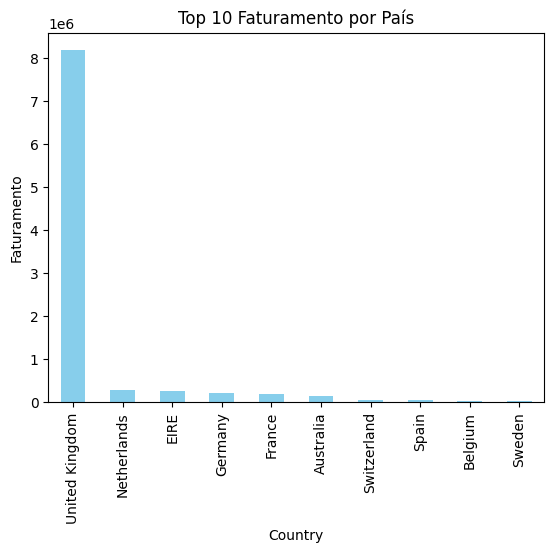

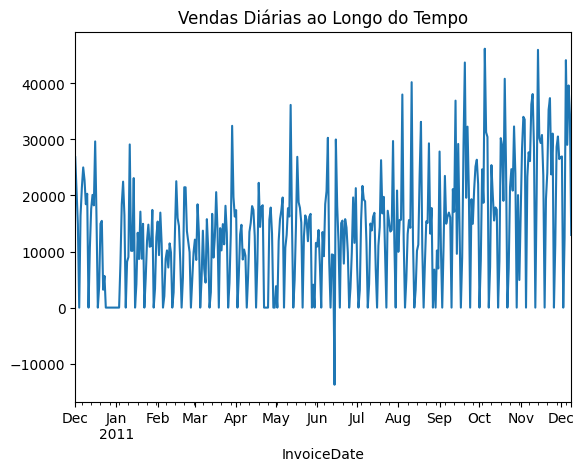

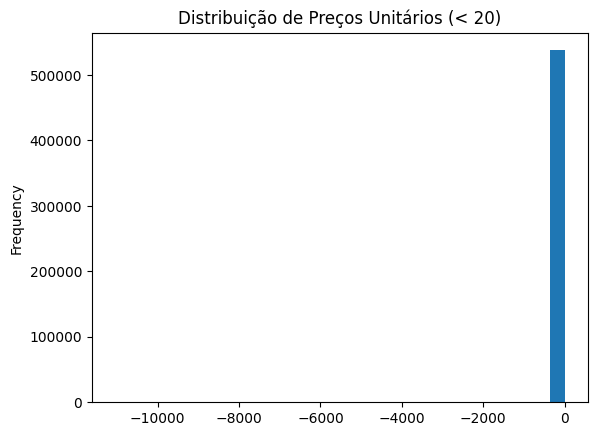

In [ ]:
import matplotlib.pyplot as plt

# 1. Gráfico de Barras (Top 10 Países por faturamento)
# Criando coluna TotalPrice para o gráfico
df_ecommerce['TotalPrice'] = df_ecommerce['Quantity'] * df_ecommerce['UnitPrice']
df_ecommerce.groupby('Country')['TotalPrice'].sum().nlargest(10).plot(kind='bar', title='Top 10 Faturamento por País', color='skyblue')
plt.ylabel('Faturamento')
plt.show()

# 2. Gráfico de Linha (Evolução Temporal)
df_ecommerce.set_index('InvoiceDate')['Quantity'].resample('D').sum().plot(kind='line', title='Vendas Diárias ao Longo do Tempo')
plt.show()

# 3. Histograma
df_ecommerce[df_ecommerce['UnitPrice'] < 20]['UnitPrice'].plot(kind='hist', bins=30, title='Distribuição de Preços Unitários (< 20)')
plt.show()

### Exercício 5.1: Gráfico de Barras

Usando `df_ecommerce`, agrupe por `Country` e calcule o `TotalPrice` total para cada país. Em seguida, crie um gráfico de barras para os 10 países com maior `TotalPrice`. Use o método `.plot(kind='bar')` diretamente do resultado do `groupby`.

In [ ]:
# Escreva aqui

### Exercício 5.2: Gráfico de Linhas (Série Temporal)

Usando `df_ecommerce`, calcule o `TotalPrice` total diário. Crie um gráfico de linhas para visualizar a tendência de vendas ao longo do tempo. Assegure-se de que o índice do seu Series resultante seja a data.

In [ ]:
# Escreva aqui

### Exercício 5.3: Histograma

Usando `df_ecommerce`, crie um histograma da coluna `UnitPrice` para entender a distribuição dos preços dos produtos. Limite o `UnitPrice` a valores menores que 100 para uma visualização mais clara (remova valores extremos que possam distorcer o gráfico).

In [ ]:
# Escreva aqui

### Exercício 5.4: Gráfico de Dispersão

Usando `df_ecommerce`, crie um gráfico de dispersão para visualizar a relação entre `Quantity` e `UnitPrice`. Observe se há algum padrão. Filtre o DataFrame para `Quantity` > 0 e `UnitPrice` > 0 para remover transações inválidas ou retornos.

In [ ]:
# Escreva aqui